## Imports et configuration
Importe les bibliothèques nécessaires (TensorFlow/Keras, OpenCV, pandas/numpy, scikit-learn, matplotlib/seaborn), configure le GPU, désactive les warnings et définit les chemins vers les images et le modèle pré-entraîné.

In [12]:
# TensorFlow and Keras Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.applications import ResNet50

# Image Processing Libraries
import cv2

# Data Handling Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# File and Operating System Libraries
import os

# Warnings Management
import warnings
warnings.filterwarnings('ignore')

# GPU Configuration
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
print(tf.config.list_physical_devices('GPU'))

IMG_PATH = "/rsna_pneumonia/Training"
MODEL_PATH = '/kaggle/input/pneumonia-detection-using-resnet50/tensorflow2/model-v1.1/2/lung_detection_2.keras'

[]


## Chargement des métadonnées
Charge les métadonnées d'entraînement et de test depuis les fichiers CSV du dataset RSNA Pneumonia.

In [4]:
train_metadata = pd.read_csv("./rsna_pneumonia/stage2_train_metadata.csv")
test_metadata = pd.read_csv("./rsna_pneumonia/stage2_test_metadata.csv")

## Aperçu du jeu d'entraînement
Affiche les informations générales du DataFrame d'entraînement (types de colonnes, valeurs non nulles, mémoire utilisée).

In [5]:
train_metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patientId  30227 non-null  str    
 1   x          9555 non-null   float64
 2   y          9555 non-null   float64
 3   width      9555 non-null   float64
 4   height     9555 non-null   float64
 5   Target     30227 non-null  int64  
 6   class      30227 non-null  str    
 7   age        30227 non-null  int64  
 8   sex        30227 non-null  str    
 9   modality   30227 non-null  str    
 10  position   30227 non-null  str    
dtypes: float64(4), int64(2), str(5)
memory usage: 2.5 MB


## Aperçu du jeu de test
Affiche les informations générales du DataFrame de test.

In [6]:
test_metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   patientId         3000 non-null   str  
 1   PredictionString  3000 non-null   str  
 2   age               3000 non-null   int64
 3   sex               3000 non-null   str  
 4   modality          3000 non-null   str  
 5   position          3000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 140.8 KB


## Statistiques numériques
Calcule les statistiques descriptives (moyenne, écart-type, min/max, quartiles) des colonnes numériques du jeu d'entraînement.

In [8]:
train_metadata.describe()

,x,y,width,height,Target,age
count,9555.000000,9555.000000,9555.000000,9555.000000,30227.000000,30227.000000
mean,394.047724,366.839560,218.471376,329.269702,0.316108,46.797764
std,204.574172,148.940488,59.289475,157.750755,0.464963,16.892940
min,2.000000,2.000000,40.000000,45.000000,0.000000,1.000000
25%,207.000000,249.000000,177.000000,203.000000,0.000000,34.000000
50%,324.000000,365.000000,217.000000,298.000000,0.000000,49.000000
75%,594.000000,478.500000,259.000000,438.000000,1.000000,59.000000
max,835.000000,881.000000,528.000000,942.000000,1.000000,155.000000


## Statistiques catégorielles
Calcule les statistiques descriptives des colonnes catégorielles (texte) du jeu d'entraînement.

In [9]:
train_metadata.describe(include='O')

C:\Users\nathc\AppData\Local\Temp\ipykernel_14164\201657019.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_metadata.describe(include='O')


,patientId,class,sex,modality,position
count,30227,30227,30227,30227,30227
unique,26684,3,2,1,2
top,0ab261f9-4eb5-42ab-a9a5-e918904d6356,No Lung Opacity / Not Normal,M,CR,AP
freq,4,11821,17216,30227,15297


## Comptage des patients
Affiche le nombre total de lignes et le nombre de patients uniques dans les métadonnées d'entraînement.

In [10]:
print('Total rows in train_labels:',train_metadata.shape[0])
print('Total unique patients in train_labels:',train_metadata['patientId'].nunique())

Total rows in train_labels: 30227
Total unique patients in train_labels: 26684


## Visualisation de la répartition des classes
Visualise la répartition des classes et leur relation avec l'âge, le sexe et la position du patient (camembert, boxplot, countplots).

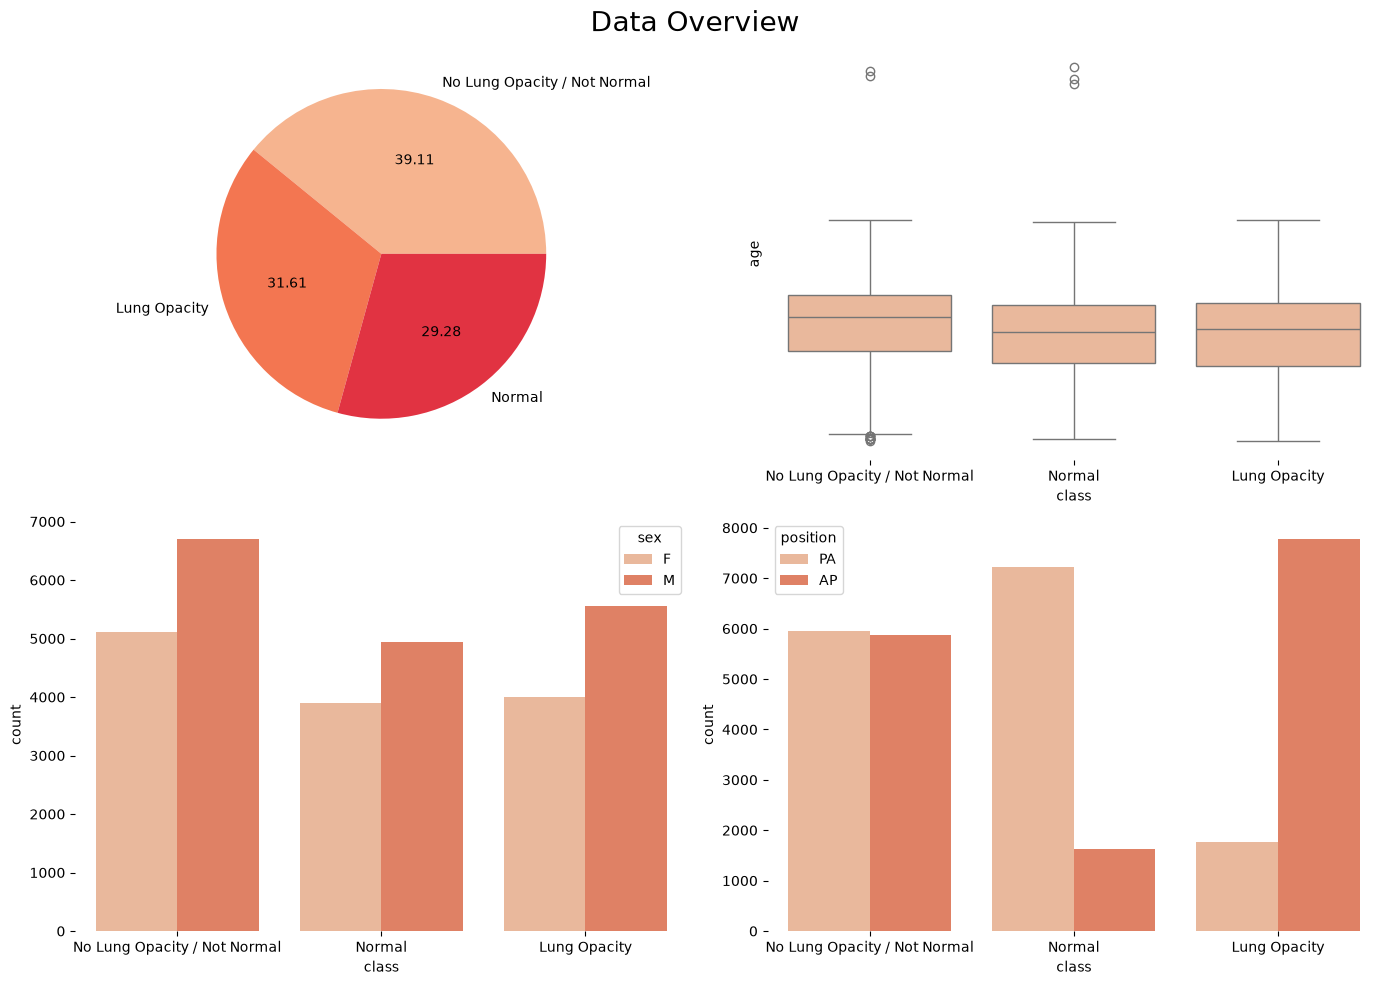

In [13]:
plt.figure(figsize=(14,10))
sns.set_palette('rocket_r')

plt.subplot(221)
agg_data = train_metadata['class'].value_counts()
plt.pie(agg_data,autopct='%4.2f',labels=agg_data.index)

plt.subplot(222)
sns.boxplot(train_metadata,x='class',y='age')
plt.yticks([])
plt.box(False)

plt.subplot(223)
sns.countplot(train_metadata,x='class',hue='sex')
plt.box(False)

plt.subplot(224)
sns.countplot(train_metadata,x='class',hue='position')
# plt.yticks([])
plt.box(False)

plt.suptitle('Data Overview',fontsize=20)
plt.tight_layout()
plt.show()

## Nettoyage des données
Supprime les colonnes de bounding box (x, y, width, height) devenues inutiles et élimine les doublons du DataFrame d'entraînement.

In [14]:
train_metadata.drop(['x','y','width','height'],axis=1,inplace=True)
train_metadata.drop_duplicates(inplace=True)